# Problem 3 - State Estimation

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description
- <b>Consider a grid for which we have sufficient metering data <i>z<sub>meter</sub></i> and discover the state vector <i>x</i> that fully characterizes the condition in which the grid is being operated, given the grid static information of its structure and corresponding component models.<b>

    _______________________________________________________________________________________________________________________

Considered "Kite" 5 Bus Network
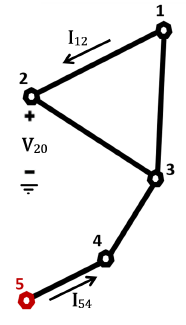

- <b>Implementation.<b>

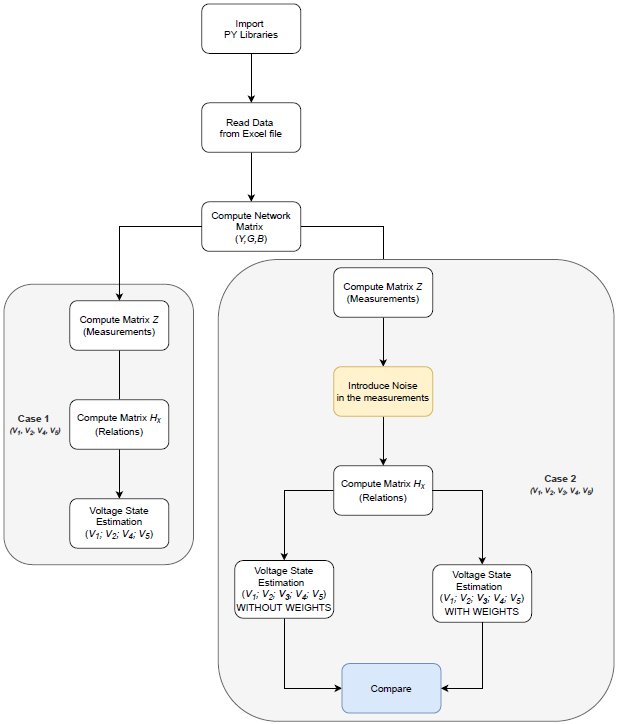

<b>Import Python Libraries

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, pinv
from itertools import combinations

<b>Parameters

In [192]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
m=100                  # Number of Iterations   
sig=0.5                # Noise factor 

<b>Import data (From Excel file)

In [193]:
Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (train)
Power_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus) - (Train)\n", Power_Info, "\n")

time=Power_Info.shape[0]
P=np.dot(-Power_Info,np.exp(complex(0,1)*np.arccos(cosPhi)))
I=np.conj(P[2,:])

Slack Bus:  5 

Lines information (Admitances)
 [[1 2 '0,01-0,1i']
 [1 3 '0,02-0,2i']
 [2 3 '0,03-0,2i']
 [3 4 '0,03-0,2i']
 [4 5 '0,02-0,2i']] 

Power consumption information (time, Bus) - (Train)
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]
 [0.684 0.528 0.256 0.44 ]] 



<b>Admittance Matrix(Y); Conductance Matrix(G); Susceptance Matrix(B)

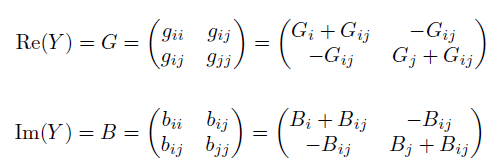

In [194]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-30.  10.  20.   0.]
 [ 10. -30.  20.   0.]
 [ 20.  20. -60.  20.]
 [  0.   0.  20. -40.]] 



<b>1º State Estimation considering complete information about currents <i>I<sub>12</sub></i> and <i>I<sub>54</sub></i> (amplitude and angle) and not estimating <i>V<sub>3</sub></i>; Page 39

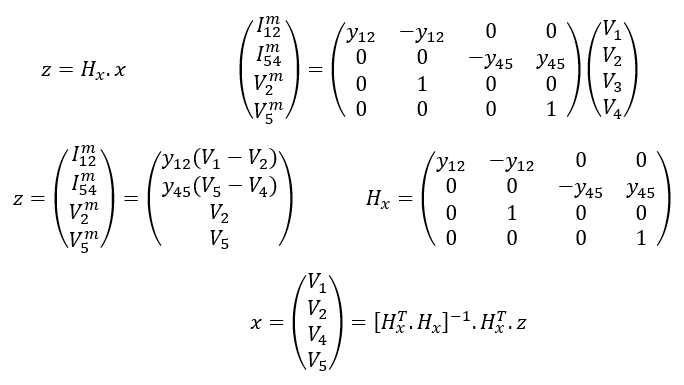

In [195]:
# Matrix Creation
v0s=np.zeros((5), dtype=complex)

# Voltage Computing (Reference)
v0s[0:4]=1+np.dot(np.linalg.inv(Yl),I)
v0s[4]=1

# Measurement values z 

# Define the true values first
z_true = np.zeros((4), dtype=complex)
z_true[0] = -Y[0,1]*(v0s[0]-v0s[1])
z_true[1] = -Y[3,4]*(v0s[4]-v0s[3])
z_true[2] = v0s[1]
z_true[3] = v0s[4]

# Add noise: True Value + (Standard Deviation * Random Normal Offset)
# Note: For complex numbers, you might want noise on both Real and Imaginary parts

z = np.zeros((4), dtype=complex)

for i in range(len(z_true)):
    z[i] = z_true[i] + (np.abs(z_true[i]) * np.random.normal(0, sig**2))


# Matrix Hx 

Hx = np.zeros((4,4), dtype=complex)
Hx[0,0] = -Y[0,1]
Hx[0,1] = Y[0,1]
Hx[1,2] = Y[3,4]
Hx[1,3] = -Y[3,4]
Hx[2,1] = 1
Hx[3,3] = 1

#State Variables (x) - These variables are the estimated voltages (V1; V2; V4; V5)

x = inv(Hx.transpose() @ Hx) @ Hx.transpose() @ z


# 1. Create the reference vector based on your mapping
# x0 -> v0s[0], x1 -> v0s[1], x2 -> v0s[3], x3 -> v0s[4]
v_ref = np.array([v0s[0], v0s[1], v0s[3], v0s[4]])

# 2. Calculate errors
# Absolute difference (complex)
error_complex = v_ref - x

# Magnitude of the error
error_mag = np.abs(error_complex)

# Percentage Error (Relative to the reference magnitude)
relative_error = (error_mag / np.abs(v_ref)) * 100

# 3. Print a formatted comparison table
print(f"{'Index':<8} | {'Estimated (x)':<25} | {'Reference (v0s)':<25} | {'Error (%)':<10}")
print("-" * 80)

indices = ["x0 (V1)", "x1 (V2)", "x2 (V4)", "x3 (V5)"]
for i in range(len(x)):
    print(f"{indices[i]:<8} | {str(np.round(x[i], 4)):<25} | {str(np.round(v_ref[i], 4)):<25} | {relative_error[i]:.4f}%")

# 4. Global Performance Metric (Mean Squared Error)
mse = np.mean(np.square(error_mag))
print(f"\nMean Squared Error: {mse:.2e}")

Index    | Estimated (x)             | Reference (v0s)           | Error (%) 
--------------------------------------------------------------------------------
x0 (V1)  | (0.4386-0.2425j)          | (0.8851-0.2433j)          | 48.6458%
x1 (V2)  | (0.433-0.2539j)           | (0.8796-0.2539j)          | 48.7815%
x2 (V4)  | (0.9527-0.1161j)          | (0.9481-0.1172j)          | 0.4995%
x3 (V5)  | (1.0045-0j)               | (1+0j)                    | 0.4536%

Mean Squared Error: 9.97e-02


<b>2º State Estimation considering RMS information of currents <i>I<sub>12</sub></i> and <i>I<sub>54</sub></i> and estimating <i>V<sub>3</sub></i>. Page 41
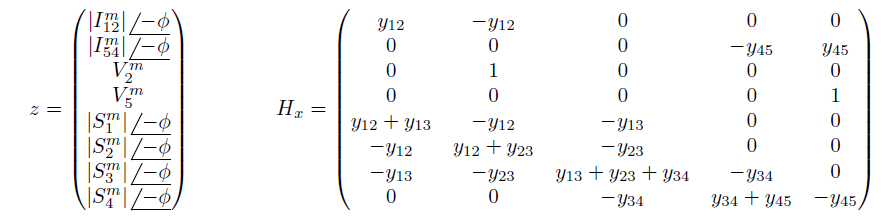

In [196]:
# Matrix Creation
b0=np.zeros((8), dtype=complex)
b1=np.zeros((8), dtype=complex)
b2=np.zeros((8), dtype=complex)
A=np.zeros((8,5), dtype=complex)
v=np.zeros((5), dtype=complex)

# Voltage Computing (Reference)
v[0:4]=1+np.dot(np.linalg.inv(Yl),I)
v[4]=1

# Measurement values z (In that case, we are computing the currents and voltages but we can also measure them).
b0[0]=np.dot(np.absolute(np.dot(-Y[0,1],(v[0]-v[1]))),np.exp(complex(0,-1)*np.arccos(cosPhi)))
b0[1]=np.dot(np.absolute(np.dot(-Y[3,4],(1-v[3]))),np.exp(complex(0,-1)*np.arccos(cosPhi)))
b0[2]=v[1]
b0[3]=1
b0[4:8]=I #In that case, we are also including the vectors of aparente power

# Matrix Hx (Page 41)

y12 = -Y[0, 1]
y13 = -Y[0, 2]
y23 = -Y[1, 2]
y34 = -Y[2, 3]
y45 = -Y[3, 4]

# Initialize an 8x5 matrix of zeros
Hx = np.zeros((8, 5), complex)

# Row 0
Hx[0, 0] = y12
Hx[0, 1] = -y12

# Row 1
Hx[1, 3] = -y45
Hx[1, 4] = y45

# Row 2 (Identity-like constraints)
Hx[2, 1] = 1

# Row 3
Hx[3, 4] = 1

# Row 4
Hx[4, 0] = y12 + y13
Hx[4, 1] = -y12
Hx[4, 2] = -y13

# Row 5
Hx[5, 0] = -y12
Hx[5, 1] = y12 + y23
Hx[5, 2] = -y23

# Row 6
Hx[6, 0] = -y13
Hx[6, 1] = -y23
Hx[6, 2] = y13 + y23 + y34
Hx[6, 3] = -y34

# Row 7
Hx[7, 2] = -y34
Hx[7, 3] = y34 + y45
Hx[7, 4] = -y45

print(Hx)


[[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]
 [ 0. +0.j  1. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  1. +0.j]
 [ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]]


<b>2º a) - First, the weight of pseudo-measurements (Matrix W) <u>are not considered</u>;

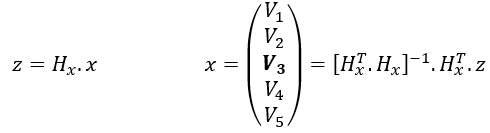

In [197]:
#Estimation not considering the noise 

x_now_nonoise = inv(Hx.transpose() @ Hx) @ Hx.transpose() @ b0

# x0 -> v0s[0], x1 -> v0s[1], x2 -> v0s[3], x3 -> v0s[4]
v_ref = v0s

# 2. Calculate errors
# Absolute difference (complex)
error_complex = v_ref - x_now_nonoise

# Magnitude of the error
error_mag = np.abs(error_complex)

# Percentage Error (Relative to the reference magnitude)
relative_error = (error_mag / np.abs(v_ref)) * 100

# 3. Print a formatted comparison table
print(f"{'Index':<8} | {'Estimated (x)':<25} | {'Reference (v0s)':<25} | {'Error (%)':<10}")
print("-" * 80)

indices = ["x0 (V1)", "x1 (V2)", "x2 (V4)", "x3 (V4)","x4 (V5)"]
for i in range(len(x_now_nonoise)):
    print(f"{indices[i]:<8} | {str(np.round(x_now_nonoise[i], 4)):<25} | {str(np.round(v_ref[i], 4)):<25} | {relative_error[i]:.4f}%")

# 4. Global Performance Metric (Mean Squared Error)
mse = np.mean(np.square(error_mag))
print(f"\nMean Squared Error: {mse:.2e}")



Index    | Estimated (x)             | Reference (v0s)           | Error (%) 
--------------------------------------------------------------------------------
x0 (V1)  | (0.8851-0.2432j)          | (0.8851-0.2433j)          | 0.0065%
x1 (V2)  | (0.8796-0.2539j)          | (0.8796-0.2539j)          | 0.0022%
x2 (V4)  | (0.8924-0.2277j)          | (0.8924-0.2278j)          | 0.0022%
x3 (V4)  | (0.948-0.1172j)           | (0.9481-0.1172j)          | 0.0021%
x4 (V5)  | (1+0j)                    | (1+0j)                    | 0.0020%

Mean Squared Error: 1.03e-09


In [198]:
for i in range(4):
    error = np.abs(b0[i]) * np.random.normal(0, 0.001)
    b1[i] = b0[i] + (error)

for i in range(4,8):
    error = np.abs(b0[i]) * np.random.normal(0, sig**2)
    b1[i] = b0[i] + (error)


x_now_noise = inv(Hx.transpose() @ Hx) @ Hx.transpose() @ b1

# 2. Calculate errors
# Absolute difference (complex)
error_complex = v_ref - x_now_noise

# Magnitude of the error
error_mag = np.abs(error_complex)

# Percentage Error (Relative to the reference magnitude)
relative_error = (error_mag / np.abs(v_ref)) * 100

# 3. Print a formatted comparison table
print(f"{'Index':<8} | {'Estimated (x)':<25} | {'Reference (v0s)':<25} | {'Error (%)':<10}")
print("-" * 80)

indices = ["x0 (V1)", "x1 (V2)", "x2 (V4)", "x3 (V4)","x4 (V5)"]
for i in range(len(x_now_noise)):
    print(f"{indices[i]:<8} | {str(np.round(x_now_noise[i], 4)):<25} | {str(np.round(v_ref[i], 4)):<25} | {relative_error[i]:.4f}%")

# 4. Global Performance Metric (Mean Squared Error)
mse = np.mean(np.square(error_mag))
print(f"\nMean Squared Error: {mse:.2e}")



Index    | Estimated (x)             | Reference (v0s)           | Error (%) 
--------------------------------------------------------------------------------
x0 (V1)  | (0.8861-0.2491j)          | (0.8851-0.2433j)          | 0.6409%
x1 (V2)  | (0.8812-0.2557j)          | (0.8796-0.2539j)          | 0.2582%
x2 (V4)  | (0.8931-0.2357j)          | (0.8924-0.2278j)          | 0.8630%
x3 (V4)  | (0.9497-0.1191j)          | (0.9481-0.1172j)          | 0.2646%
x4 (V5)  | (1.002+0.0018j)           | (1+0j)                    | 0.2653%

Mean Squared Error: 2.34e-05


<b>2º b) - Second, the weight of pseudo-measurements (Matrix W) <u>are considered</u>;
    
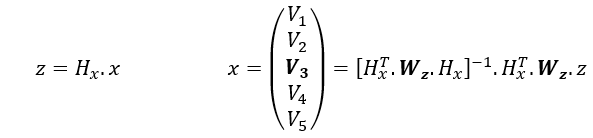

In [199]:
W = np.zeros((8,8), dtype=complex)


for i in range(4):
    error = np.abs(b0[i]) * np.random.normal(0, 0.001)
    b1[i] = b0[i] + (error)
    W[i,i] = 1 / (error**2)

for i in range(4,8):
    error = np.abs(b0[i]) * np.random.normal(0, sig**2)
    b1[i] = b0[i] + (error)
    W[i,i] = 1 / (error**2)

x_w_noise = inv(Hx.transpose() @ W @ Hx) @ Hx.transpose() @ W @ b1

# 2. Calculate errors
# Absolute difference (complex)
error_complex = v_ref - x_w_noise

# Magnitude of the error
error_mag = np.abs(error_complex)

# Percentage Error (Relative to the reference magnitude)
relative_error = (error_mag / np.abs(v_ref)) * 100

# 3. Print a formatted comparison table
print(f"{'Index':<8} | {'Estimated (x)':<25} | {'Reference (v0s)':<25} | {'Error (%)':<10}")
print("-" * 80)

indices = ["x0 (V1)", "x1 (V2)", "x2 (V4)", "x3 (V4)","x4 (V5)"]
for i in range(len(x_w_noise)):
    print(f"{indices[i]:<8} | {str(np.round(x_w_noise[i], 4)):<25} | {str(np.round(v_ref[i], 4)):<25} | {relative_error[i]:.4f}%")

# 4. Global Performance Metric (Mean Squared Error)
mse = np.mean(np.square(error_mag))
print(f"\nMean Squared Error: {mse:.2e}")

Index    | Estimated (x)             | Reference (v0s)           | Error (%) 
--------------------------------------------------------------------------------
x0 (V1)  | (0.8863-0.2441j)          | (0.8851-0.2433j)          | 0.1571%
x1 (V2)  | (0.8815-0.255j)           | (0.8796-0.2539j)          | 0.2358%
x2 (V4)  | (0.8928-0.2274j)          | (0.8924-0.2278j)          | 0.0595%
x3 (V4)  | (0.9482-0.1172j)          | (0.9481-0.1172j)          | 0.0148%
x4 (V5)  | (1.0001+0j)               | (1+0j)                    | 0.0143%

Mean Squared Error: 1.42e-06


In [200]:
def calculate_average_errors(Hx, b0, sig, Y, v0s, N=1000):

    # Reference values
    ref_01 = -Y[0,1] * (v0s[0] - v0s[1])
    ref_34 = -Y[3,4] * (v0s[4] - v0s[3])

    # Accumulators for output-variable errors
    total_error = np.zeros(2)

    for _ in range(N):

        for i in range(4):
            error = np.abs(b0[i]) * np.random.normal(0, 0.001)
            b1[i] = b0[i] + (error)
            W[i,i] = 1 / (error**2)

        for i in range(4,8):
            error = np.abs(b0[i]) * np.random.normal(0, sig**2)
            b1[i] = b0[i] + (error)
            W[i,i] = 1 / (error**2)

        x_est = inv(Hx.transpose() @ W @ Hx) @ Hx.transpose() @ W @ b1

        # 3. Compute output variables from estimated state
        flow_01 = -Y[0,1] * (x_est[0] - x_est[1])
        flow_34 = -Y[3,4] * (x_est[4] - x_est[3])

        # 4. Compute percent error for this run
        err_01 = np.abs((flow_01 - ref_01) / ref_01) * 100
        err_34 = np.abs((flow_34 - ref_34) / ref_34) * 100

        total_error[0] += err_01
        total_error[1] += err_34

        if err_01 < 0 or err_34 < 0:
            print("flow_01:", flow_01, "ref_01:", ref_01, "err_01:", err_01)

    # 5. Average percent error
    avg_error = total_error / N
    avg_error = 1-avg_error

    return avg_error

In [201]:
def calculate_average_errors_no_w(Hx, b0, sig, Y, v0s, N=1000):

    # Reference values
    ref_01 = -Y[0,1] * (v0s[0] - v0s[1])
    ref_34 = -Y[3,4] * (v0s[4] - v0s[3])

    # Accumulators for output-variable errors
    total_error = np.zeros(2)

    for _ in range(N):

        for i in range(4):
            error = np.abs(b0[i]) * np.random.normal(0, 0.001)
            b1[i] = b0[i] + (error)

        for i in range(4,8):
            error = np.abs(b0[i]) * np.random.normal(0, sig**2)
            b1[i] = b0[i] + (error)


        x_est = inv(Hx.transpose() @ Hx) @ Hx.transpose() @ b1

        # 3. Compute output variables from estimated state
        flow_01 = -Y[0,1] * (x_est[0] - x_est[1])
        flow_34 = -Y[3,4] * (x_est[4] - x_est[3])

        # 4. Compute percent error for this run
        err_01 = np.abs((flow_01 - ref_01) / ref_01) * 100
        err_34 = np.abs((flow_34 - ref_34) / ref_34) * 100

        total_error[0] += err_01
        total_error[1] += err_34

        if err_01 < 0 or err_34 < 0:
            print("flow_01:", flow_01, "ref_01:", ref_01, "err_01:", err_01)

    # 5. Average percent error
    avg_error = total_error / N
    avg_error = 1-avg_error

    return avg_error

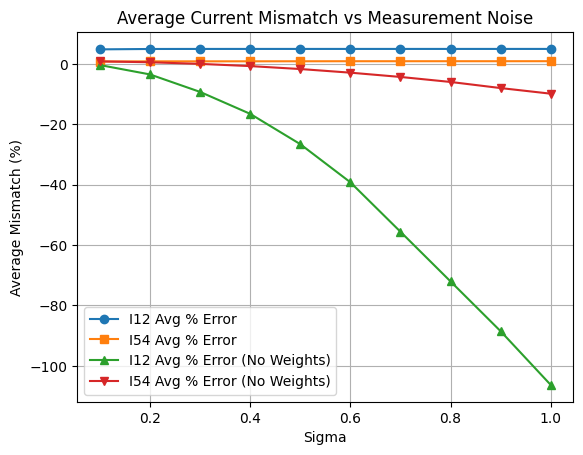

In [202]:
###PLOT RESULTS

 
sigmas = np.arange(0.1, 1.01, 0.1)

results = []
results_now_w = []

for sig in sigmas:
    avg_err = calculate_average_errors(Hx, b0, sig, Y, v0s, N=1000)
    avg_err_no_w = calculate_average_errors_no_w(Hx, b0, sig, Y, v0s, N=1000)
    results.append(avg_err)
    results_now_w.append(avg_err_no_w)

# Convert to real-valued array
results = np.array(results, dtype=float)   # force real dtype
results = np.abs(results)                  # elementwise magnitude

error_01 = results[:,0]
error_34 = results[:,1]
error_01_no_w = np.array(results_now_w)[:,0]
error_34_no_w = np.array(results_now_w)[:,1]


plt.figure()
plt.plot(sigmas, error_01, marker='o', label='I12 Avg % Error')
plt.plot(sigmas, error_34, marker='s', label='I54 Avg % Error')
plt.plot(sigmas, error_01_no_w, marker='^', label='I12 Avg % Error (No Weights)')
plt.plot(sigmas, error_34_no_w, marker='v', label='I54 Avg % Error (No Weights)')

plt.xlabel('Sigma')
plt.ylabel('Average Mismatch (%)')
plt.title('Average Current Mismatch vs Measurement Noise')
plt.legend()
plt.grid(True)
plt.show()

# Extra Project Goals
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- Assume you have to chose just two out of four possible pseudo-measurements, S<sup>m</sup><sub>1</sub> , S<sup>m</sup><sub>2</sub> , S<sup>m</sup><sub>3</sub> , S<sup>m</sup><sub>4</sub> . What would be your choices and why? Chose based on probable accuracy of the resulting estimation.
- Assume that <i>I<sub>12</sub>=0</i>. Under this assumption, one of two possible situations may be occuring: either branch 1-2 is out of service (<i>y<sub>12</sub>=0</i>) or the corresponding current meter is malfunctioning. Decide about the most probable situation based on the accuracy of the corresponding estimation. as in the previous exercice, use the matrix <i>R<sub>x</sub></i> andd consider different matrices <i>W<sub>z</sub></i> including the identity matrix. Elaborate on the effects of <i>W<sub>z</sub></i>.  


In [203]:
sig = 0.5
Nsim = 1000  # number of Monte Carlo runs per combination

# Keep first 4 rows/entries fixed
first_four_Hx = Hx[:4, :]
first_four_b = b0[:4]

# Last 4 rows/entries
last_four_Hx = Hx[-4:, :]
last_four_b = b0[-4:]

# To store average traces of covariance matrices
trace_vec = []

# Preallocate b_new
b_new = np.zeros(6, dtype=complex)

# Loop over all combinations of 2 rows from last 4
for row_indices in combinations(range(4), 2):
    # Construct Hx_reduced and b_reduced
    Hx_reduced = np.vstack([first_four_Hx, last_four_Hx[list(row_indices), :]])
    b_reduced = np.hstack([first_four_b, last_four_b[list(row_indices)]])

    traces = []  # store traces for Monte Carlo runs

    for _ in range(Nsim):
        # Initialize W
        W = np.zeros((6,6), dtype=complex)

        # Perturb b_new and fill W for first 4 entries
        for i in range(4):
            error = np.abs(b_reduced[i]) * np.random.normal(0, 0.001)
            b_new[i] = b_reduced[i] + error
            W[i,i] = 1 / (error**2) if error != 0 else 1e12  # avoid division by 0

        # Perturb last 2 entries (the selected ones)
        for i in range(4,6):
            error = np.abs(b_reduced[i]) * np.random.normal(0, sig**2)
            b_new[i] = b_reduced[i] + error
            W[i,i] = 1 / (error**2) if error != 0 else 1e12

        # Compute covariance estimate
        cov_est = inv(Hx_reduced.T @ W @ Hx_reduced)

        # Store trace
        traces.append(np.trace(cov_est))

    # Store mean trace for this combination
    trace_vec.append(np.mean(traces))

# Convert to numpy array if needed
trace_vec = np.array(trace_vec)

print("Average traces for all combinations:", trace_vec)

# Re-create the list of combinations (same as used for trace_vec)
comb_list = list(combinations(range(4), 2))

# Find index of minimum trace
min_idx = np.argmin(trace_vec)

# Get the combination that corresponds to that minimum
min_combination = comb_list[min_idx]

print("Combination with minimum trace:", min_combination)
print("Minimum trace value:", trace_vec[min_idx])

Average traces for all combinations: [ 3.90481000e-07+9.36300333e-07j  3.84178361e-07+1.09136667e-06j
  3.09664135e-06+2.19622415e-06j -8.35446833e-06+3.76783070e-06j
  3.46741636e-06+1.19715956e-06j  3.92732702e-06+8.86006586e-07j]
Combination with minimum trace: (1, 2)
Minimum trace value: (-8.35446833257544e-06+3.767830697208872e-06j)


DESAFIO EXTRA 2:

Calculations
[Identity] Hypothesis A (Broken Line):
Erro ResiduaL : 1.7558e-05
Traço de Rx : 2.5149e+00

[Identity] Hypothesis B (Faulty Sensor):
Erro ResiduaL : 1.2852e-02
Traço de Rx : 2.5118e+00

Calculations
[Wz Weights] Hypothesis A (Broken Line):
Erro ResiduaL : 2.8861e-02
Traço de Rx : 1.0809e-03

[Wz Weights] Hypothesis B (Faulty Sensor):
Erro ResiduaL : 5.0213e-01
Traço de Rx : 5.5731e-05



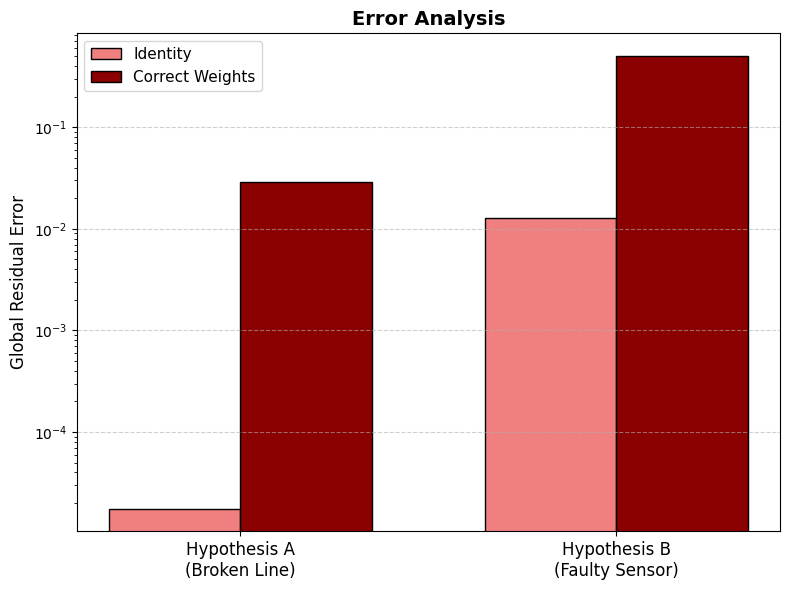

In [ ]:
###Second Challenge
#Simular a anomalia
b_anom = np.copy(b0)
b_anom[0] = 0 + 0j  

# riar as Matrizes de Pesos (Wz)
#Matriz Identidade
W_ident = np.eye(8, dtype=complex)

#Matriz de Pesos Real Wz
W_proper = np.zeros((8, 8), dtype=complex)
for i in range(8):
    current_sig = 0.001 if i < 4 else sig
    W_proper[i, i] = 1 / (current_sig**2)

#HIP A
Hx_A = np.copy(Hx)
y12_A = 0 + 0j

Hx_A[0, 0] = y12_A;        Hx_A[0, 1] = -y12_A            
Hx_A[4, 0] = y12_A + y13;  Hx_A[4, 1] = -y12_A            
Hx_A[5, 0] = -y12_A;       Hx_A[5, 1] = y12_A + y23       

Hx_B = np.copy(Hx) 

def evaluate_hypothesis(H, W, z, desc, weight_desc):
    try:
        HT_W = H.conj().T @ W
        x_est = inv(HT_W @ H) @ HT_W @ z
        residuals = z - (H @ x_est)
        J_x = np.abs(residuals.conj().T @ W @ residuals)
        Rx = inv(HT_W @ H)
        trace_Rx = np.abs(np.trace(Rx))
        
        print(f"[{weight_desc}] {desc}:")
        print(f"Erro ResiduaL : {J_x:.4e}")
        print(f"Traço de Rx : {trace_Rx:.4e}\n")
        
    except np.linalg.LinAlgError:
        print(f"[{weight_desc}] {desc}\n")

print("Calculations")
evaluate_hypothesis(Hx_A, W_ident, b_anom, "Hypothesis A (Broken Line)", "Identity")
evaluate_hypothesis(Hx_B, W_ident, b_anom, "Hypothesis B (Faulty Sensor)", "Identity")

print("Calculations")
evaluate_hypothesis(Hx_A, W_proper, b_anom, "Hypothesis A (Broken Line)", "Wz Weights")
evaluate_hypothesis(Hx_B, W_proper, b_anom, "Hypothesis B (Faulty Sensor)", "Wz Weights")


def get_metrics_Jx(H, W, z):
    try:
        HT_W = H.conj().T @ W
        x_est = inv(HT_W @ H) @ HT_W @ z
        residuals = z - (H @ x_est)
        # Calcular apenas o J(x)
        J_x = np.abs(residuals.conj().T @ W @ residuals)
        return J_x
    except np.linalg.LinAlgError:
        return 0

labels = ['Hypothesis A\n(Broken Line)', 'Hypothesis B\n(Faulty Sensor)']

jx_ident = []
jx_pesos = []

# Recolher dados com Matriz Identidade
for H in [Hx_A, Hx_B]:
    j = get_metrics_Jx(H, W_ident, b_anom)
    jx_ident.append(j)

# Recolher dados com Matriz de Pesos 
for H in [Hx_A, Hx_B]:
    j = get_metrics_Jx(H, W_proper, b_anom)
    jx_pesos.append(j)


x = np.arange(len(labels))  
width = 0.35 

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, jx_ident, width, label='Identity', color='lightcoral', edgecolor='black')
plt.bar(x + width/2, jx_pesos, width, label='Correct Weights', color='darkred', edgecolor='black')
plt.ylabel('Global Residual Error', fontsize=12)
plt.title('Error Analysis', fontsize=14, fontweight='bold')
plt.xticks(x, labels, fontsize=12)
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Base Rx Trace: 5.5731e-05
Rx Trace WITH PMU: 3.9965e-06



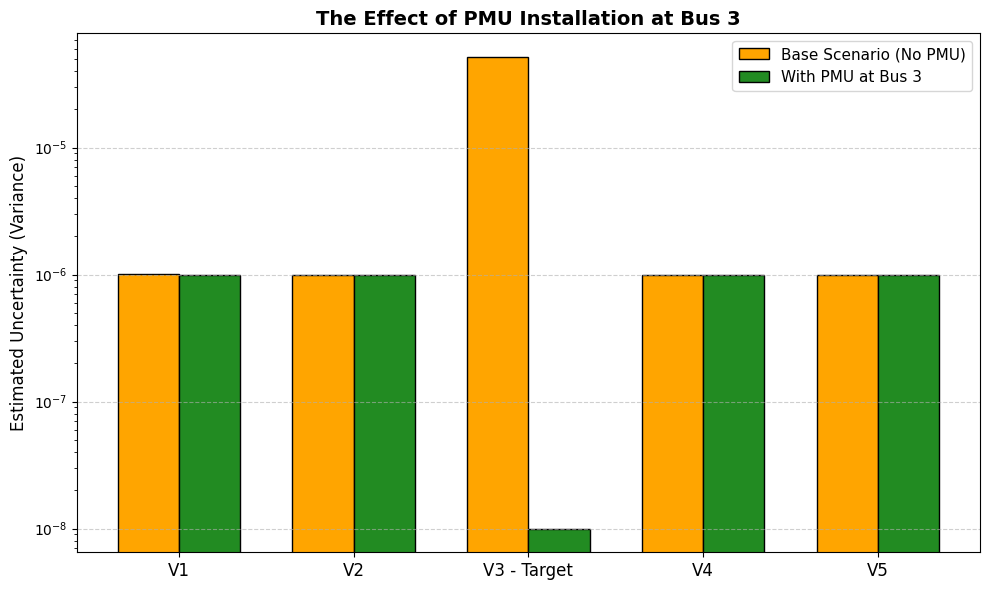

In [205]:
HT_W_base = Hx.conj().T @ W_proper
Rx_base = inv(HT_W_base @ Hx)
uncertainty_base = np.abs(np.diagonal(Rx_base))

Hx_pmu = np.zeros((9, 5), dtype=complex)
Hx_pmu[:8, :] = Hx
Hx_pmu[8, 2] = 1 + 0j 

W_pmu = np.zeros((9, 9), dtype=complex)
W_pmu[:8, :8] = W_proper
pmu_error = 0.0001
W_pmu[8, 8] = 1 / (pmu_error**2)

HT_W_pmu = Hx_pmu.conj().T @ W_pmu
Rx_pmu = inv(HT_W_pmu @ Hx_pmu)
uncertainty_pmu = np.abs(np.diagonal(Rx_pmu))

print(f"Base Rx Trace: {np.sum(uncertainty_base):.4e}")
print(f"Rx Trace WITH PMU: {np.sum(uncertainty_pmu):.4e}\n")

labels = ['V1', 'V2', 'V3 - Target', 'V4', 'V5']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, uncertainty_base, width, label='Base Scenario (No PMU)', color='orange', edgecolor='black')
plt.bar(x + width/2, uncertainty_pmu, width, label='With PMU at Bus 3', color='forestgreen', edgecolor='black')

plt.ylabel('Estimated Uncertainty (Variance)', fontsize=12)
plt.title('The Effect of PMU Installation at Bus 3', fontsize=14, fontweight='bold')
plt.xticks(x, labels, fontsize=12)
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
